## SPRINT 10 - Analítica de datos en Pandas

#NIVEL 1

In [1]:
# NIVEL 1 - Ejercicio 1

# Importa como un DataFrame el archivo sprint10.xlsx. Asegúrate de que el archivo se importa correctamente, 
# con los nombres de columnas que le corresponden, sin manipular el archivo original.

import pandas as pd

ruta = '/Users/rafafons/Library/Mobile Documents/com~apple~CloudDocs/2_Rafa/01-Capacitaciones/IT Academy/sprint 10 python/sprint10.xlsx'
df = pd.read_excel(ruta, header=3, index_col=0)
df	

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
0,Inês,Ferreira Silva,16928694K,Portugal,Lisboa,25,2,1953,D,1.144 €,NaN,1.0,Grup B
1,Clara,Sánchez Martínez,27724652S,Espanya,Barcelona,18,3,1996,D,1.253 €,1.0,NaN,Grup A
2,Fatima,Fassi,38141675A,Marroc,Rabat,6,11,2005,A,1.441 €,1.0,NaN,Grup A
3,Khadija,Bennani Bennani,59157262R,Marroc,Rabat,20,1,1995,D,1.944 €,NaN,1.0,Grup B
4,Toni,Sánchez García,69630528M,Espanya,Barcelona,9,8,1999,H,1.043 €,NaN,1.0,Grup A
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Marta,Ferrer Ferrer,25161375F,Espanya,Sevilla,1,6,1951,D,1.216 €,NaN,1.0,Grup B
996,Joan,García,52145541P,Espanya,Sevilla,11,4,1959,H,971 €,NaN,1.0,Grup A
997,Laia,Ferrer Martínez,69760120X,Espanya,Barcelona,11,11,1980,D,682 €,NaN,1.0,Grup A
998,Jordi,García,82947791W,Espanya,Barcelona,23,5,1984,H,1.699 €,1.0,NaN,Grup C


In [2]:
# Ordena el DataFrame por el país de origen. En caso de empate, ordena por el nombre de la ciudad.
# Muestra las primeras 10 filas.

df.sort_values(["País d'origen", "Ciutat"]).head(10)

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
871,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
281,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.0,Grup A
435,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.0,Grup C
444,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C
487,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B


In [3]:
# Realiza un print donde compruebe que el DNI sólo tiene valores únicos.

#chequeo si hay algun repetido
if len(df) == len(df["DNI"].unique()):
    print("Los DNIs no se repiten")
else:
    # si hay repetido guardo los datos
    print("Existen DNIs repetidos")
    dnis_unicos = df["DNI"].unique()
    duplicados = {}

    for dni in dnis_unicos:
        filas = list(df.index[df["DNI"] == dni])       # index devuelve el num de filas donde sea True la condición
        if len(filas) >= 1:  # solo me quedo con los repetidos
            duplicados[dni] = filas
    print(duplicados)

Los DNIs no se repiten


In [4]:
# NIVEL 1 - Ejercicio 2

# Crea una columna que sea el nombre completo.
for i in range(len(df)):
    df.loc[i,"Apellido y nombre"]= df.loc[i,"Cognoms"]+" "+df.loc[i,"Nom"]

df[["Apellido y nombre"]]


,Apellido y nombre
0,Ferreira Silva Inês
1,Sánchez Martínez Clara
2,Fassi Fatima
3,Bennani Bennani Khadija
4,Sánchez García Toni
...,...
995,Ferrer Ferrer Marta
996,García Joan
997,Ferrer Martínez Laia
998,García Jordi


In [5]:
# Crea una columna si la persona ha nacido en España o no.
for i in range(len(df)):
    if df.loc[i,"País d'origen"]== "Espanya":
        df.loc[i,"Nació en España?"]= True
    else: 
        df.loc[i,"Nació en España?"]= False

df[["País d'origen", "Nació en España?"]]


,País d'origen,Nació en España?
0,Portugal,False
1,Espanya,True
2,Marroc,False
3,Marroc,False
4,Espanya,True
...,...,...
995,Espanya,True
996,Espanya,True
997,Espanya,True
998,Espanya,True


In [6]:
# Pone el DNI como índice del DataFrame (nombres de filas).

df = df.set_index(["DNI"], drop=True)
df = pd.DataFrame(df)
df


,Nom,Cognoms,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Apellido y nombre,Nació en España?
DNI,,,,,,,,,,,,,,
16928694K,Inês,Ferreira Silva,Portugal,Lisboa,25,2,1953,D,1.144 €,NaN,1.0,Grup B,Ferreira Silva Inês,False
27724652S,Clara,Sánchez Martínez,Espanya,Barcelona,18,3,1996,D,1.253 €,1.0,NaN,Grup A,Sánchez Martínez Clara,True
38141675A,Fatima,Fassi,Marroc,Rabat,6,11,2005,A,1.441 €,1.0,NaN,Grup A,Fassi Fatima,False
59157262R,Khadija,Bennani Bennani,Marroc,Rabat,20,1,1995,D,1.944 €,NaN,1.0,Grup B,Bennani Bennani Khadija,False
69630528M,Toni,Sánchez García,Espanya,Barcelona,9,8,1999,H,1.043 €,NaN,1.0,Grup A,Sánchez García Toni,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25161375F,Marta,Ferrer Ferrer,Espanya,Sevilla,1,6,1951,D,1.216 €,NaN,1.0,Grup B,Ferrer Ferrer Marta,True
52145541P,Joan,García,Espanya,Sevilla,11,4,1959,H,971 €,NaN,1.0,Grup A,García Joan,True
69760120X,Laia,Ferrer Martínez,Espanya,Barcelona,11,11,1980,D,682 €,NaN,1.0,Grup A,Ferrer Martínez Laia,True


In [7]:
# Sustituye el nombre de las columnas Día de Nacimiento, Mes de Nacimiento y Año de Nacimiento por Día, Mes y Año.
df = df.rename(columns={"Dia de Naixement":"Día", 'Mes de Naixement':"Mes", 'Any de Naixement':"Año"})
df


,Nom,Cognoms,País d'origen,Ciutat,Día,Mes,Año,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Apellido y nombre,Nació en España?
DNI,,,,,,,,,,,,,,
16928694K,Inês,Ferreira Silva,Portugal,Lisboa,25,2,1953,D,1.144 €,NaN,1.0,Grup B,Ferreira Silva Inês,False
27724652S,Clara,Sánchez Martínez,Espanya,Barcelona,18,3,1996,D,1.253 €,1.0,NaN,Grup A,Sánchez Martínez Clara,True
38141675A,Fatima,Fassi,Marroc,Rabat,6,11,2005,A,1.441 €,1.0,NaN,Grup A,Fassi Fatima,False
59157262R,Khadija,Bennani Bennani,Marroc,Rabat,20,1,1995,D,1.944 €,NaN,1.0,Grup B,Bennani Bennani Khadija,False
69630528M,Toni,Sánchez García,Espanya,Barcelona,9,8,1999,H,1.043 €,NaN,1.0,Grup A,Sánchez García Toni,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25161375F,Marta,Ferrer Ferrer,Espanya,Sevilla,1,6,1951,D,1.216 €,NaN,1.0,Grup B,Ferrer Ferrer Marta,True
52145541P,Joan,García,Espanya,Sevilla,11,4,1959,H,971 €,NaN,1.0,Grup A,García Joan,True
69760120X,Laia,Ferrer Martínez,Espanya,Barcelona,11,11,1980,D,682 €,NaN,1.0,Grup A,Ferrer Martínez Laia,True


In [8]:
# Sustituye a H por Hombre, D por Mujer, A por Otros y NC por un dato faltante (enano/null/na).
for i in df.index:
    match df.loc[i,"Gènere"]:
        case  "D":
            df.loc[i,"Gènere"] = "Mujer"
        case  "H":
            df.loc[i,"Gènere"] = "Hombre"
        case  "A":
            df.loc[i,"Gènere"] = "Otros"
        case  _:
            df.loc[i,"Gènere"] = "NC" 

df
# Muestra todos los cambios que has realizado en una sola tabla.

,Nom,Cognoms,País d'origen,Ciutat,Día,Mes,Año,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Apellido y nombre,Nació en España?
DNI,,,,,,,,,,,,,,
16928694K,Inês,Ferreira Silva,Portugal,Lisboa,25,2,1953,Mujer,1.144 €,NaN,1.0,Grup B,Ferreira Silva Inês,False
27724652S,Clara,Sánchez Martínez,Espanya,Barcelona,18,3,1996,Mujer,1.253 €,1.0,NaN,Grup A,Sánchez Martínez Clara,True
38141675A,Fatima,Fassi,Marroc,Rabat,6,11,2005,Otros,1.441 €,1.0,NaN,Grup A,Fassi Fatima,False
59157262R,Khadija,Bennani Bennani,Marroc,Rabat,20,1,1995,Mujer,1.944 €,NaN,1.0,Grup B,Bennani Bennani Khadija,False
69630528M,Toni,Sánchez García,Espanya,Barcelona,9,8,1999,Hombre,1.043 €,NaN,1.0,Grup A,Sánchez García Toni,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25161375F,Marta,Ferrer Ferrer,Espanya,Sevilla,1,6,1951,Mujer,1.216 €,NaN,1.0,Grup B,Ferrer Ferrer Marta,True
52145541P,Joan,García,Espanya,Sevilla,11,4,1959,Hombre,971 €,NaN,1.0,Grup A,García Joan,True
69760120X,Laia,Ferrer Martínez,Espanya,Barcelona,11,11,1980,Mujer,682 €,NaN,1.0,Grup A,Ferrer Martínez Laia,True


In [9]:
# NIVEL 1 - Eercicio 3

# Junta las columnas Hijos y No Hijos en una sola columna, utilizando el método .apply() y definiendo una función que resuelva el problema.
def hijos_si(campo):
    if campo == 1:
        salida ="Si"
    else:
        salida = "No"
    
    return salida

In [10]:
# La columna nueva debe llamarse "Hijos" y tomar los valores "Sí" o "No".
df["Hijos?"] = df["Fills"].apply(hijos_si)
df.drop(["Fills", "No Fills"], axis=1, inplace=True)
df

,Nom,Cognoms,País d'origen,Ciutat,Día,Mes,Año,Gènere,Salari mensual,Grup Professional,Apellido y nombre,Nació en España?,Hijos?
DNI,,,,,,,,,,,,,
16928694K,Inês,Ferreira Silva,Portugal,Lisboa,25,2,1953,Mujer,1.144 €,Grup B,Ferreira Silva Inês,False,No
27724652S,Clara,Sánchez Martínez,Espanya,Barcelona,18,3,1996,Mujer,1.253 €,Grup A,Sánchez Martínez Clara,True,Si
38141675A,Fatima,Fassi,Marroc,Rabat,6,11,2005,Otros,1.441 €,Grup A,Fassi Fatima,False,Si
59157262R,Khadija,Bennani Bennani,Marroc,Rabat,20,1,1995,Mujer,1.944 €,Grup B,Bennani Bennani Khadija,False,No
69630528M,Toni,Sánchez García,Espanya,Barcelona,9,8,1999,Hombre,1.043 €,Grup A,Sánchez García Toni,True,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25161375F,Marta,Ferrer Ferrer,Espanya,Sevilla,1,6,1951,Mujer,1.216 €,Grup B,Ferrer Ferrer Marta,True,No
52145541P,Joan,García,Espanya,Sevilla,11,4,1959,Hombre,971 €,Grup A,García Joan,True,No
69760120X,Laia,Ferrer Martínez,Espanya,Barcelona,11,11,1980,Mujer,682 €,Grup A,Ferrer Martínez Laia,True,No


In [11]:
# NIVEL 1 - Eercicio 4

# Crea una tabla resumen que permita ver el sueldo medio,  mínimo y máximo por Género.

# transformo los datos en numericos
try:
    df["Salari mensual"] = df["Salari mensual"].str.replace(".","", regex=False)
    df["Salari mensual"] = df["Salari mensual"].str.replace("€","", regex=False)
    df["Salari mensual"] = df["Salari mensual"].str.strip()
    df["Salari mensual"] = pd.to_numeric(df["Salari mensual"], errors="coerce")
except:
    print("hay errores seguramente porque el campo df[Salari mensual] ya fue transformado")
    
#hago la agrupacion
df.groupby(["Gènere"]).agg({"Salari mensual":["mean", "max", "min"]}).round(2)


Salari mensual           
                 mean   max  min
Gènere                          
Hombre        1643.25  3356  737
Mujer         1469.44  3021  665
NC            1568.87  2969  758
Otros         1626.59  3175  703

In [12]:
# Ordena la tabla en función del sueldo medio
df.groupby(["Gènere"]).agg(promedio=("Salari mensual","mean")).sort_values(["promedio"], ascending=False).round(2)


,promedio
Gènere,
Hombre,1643.25
Otros,1626.59
NC,1568.87
Mujer,1469.44


In [13]:
# NIVEL 1 - Ejercicio 5

# Crea una tabla resumen con el salario medio por género (filas) y país de origen (columnas).
# Añade las medias a los márgenes de la mesa.

tabla = pd.crosstab(
    df["Gènere"],               # filas
    df["País d'origen"],        # columnas
    df[["Salari mensual"]], aggfunc="mean",     #funcion de agregacion
    margins=True                # funcion de agregacion por columna y fila               
    ).round(0)                  # round
tabla

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,All
Gènere,,,,,,,,,,,
Hombre,2067.0,1583.0,1555.0,1682.0,1389.0,1673.0,1531.0,1625.0,1497.0,1163.0,1643.0
Mujer,1804.0,1292.0,1498.0,1460.0,1566.0,1247.0,1405.0,1518.0,1489.0,1489.0,1469.0
NC,1932.0,1136.0,1252.0,1597.0,1573.0,1316.0,1366.0,1583.0,1554.0,1758.0,1569.0
Otros,951.0,1141.0,1030.0,1706.0,NaN,1423.0,1365.0,1372.0,1765.0,1921.0,1627.0
All,1858.0,1432.0,1489.0,1582.0,1465.0,1421.0,1442.0,1559.0,1527.0,1448.0,1561.0


In [14]:
# (EXTRA): Aplica formato condicional en la tabla para ver en un color más intenso los valores más elevados

# para hacer una degracioan de colores de mas de 1 color, hay q importar una libreria
from matplotlib.colors import LinearSegmentedColormap
colores_grad = LinearSegmentedColormap.from_list("rojo_verde", ["lightcoral","lightyellow", "green"])       # (min , max)

tabla_format = (tabla.style
    .background_gradient(cmap=colores_grad, vmin=1000, vmax=2000)
    .format("{:.0f}")
    #.highlight_max(axis=1, color='green')  # máximos por columna
    #.highlight_min(axis=1, color='lightcoral')  # mínimos por fila
)
tabla_format

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,All
Gènere,,,,,,,,,,,
Hombre,2067,1583,1555,1682,1389,1673,1531,1625,1497,1163,1643
Mujer,1804,1292,1498,1460,1566,1247,1405,1518,1489,1489,1469
NC,1932,1136,1252,1597,1573,1316,1366,1583,1554,1758,1569
Otros,951,1141,1030,1706,nan,1423,1365,1372,1765,1921,1627
All,1858,1432,1489,1582,1465,1421,1442,1559,1527,1448,1561


In [15]:
# NIVEL 1 - Ejercicio 6

# Crea una nueva columna que sea la fecha de nacimiento en formato Datetime a partir de las columnas día, mes y año.
import pandas as pd
df["Fecha Nac."] = pd.to_datetime(
    df["Año"].astype(str) + "-" +
    df["Mes"].astype(str) + "-" +
    df["Día"].astype(str),
    format="%Y-%m-%d"
)

df[["Fecha Nac."]]


,Fecha Nac.
DNI,
16928694K,1953-02-25
27724652S,1996-03-18
38141675A,2005-11-06
59157262R,1995-01-20
69630528M,1999-08-09
...,...
25161375F,1951-06-01
52145541P,1959-04-11
69760120X,1980-11-11


In [16]:
# Utilizando esta columna crea una función que dada una fecha, te calcule la edad actual a día de hoy.

def edad(fecha_nac):
    from datetime import date
    fecha_nac = pd.to_datetime(fecha_nac).date()            #transformo primero a timestamp y luego a date
    dif_fechas = (date.today() - fecha_nac).days/365.25
    
    return round(dif_fechas,0)

In [17]:
# Utiliza la función que acabas de crear para generar una columna nueva en DataFrame con la edad actual.

df['Edad'] = df['Fecha Nac.'].apply(edad)

df[["Fecha Nac.", 'Edad']]

,Fecha Nac.,Edad
DNI,,
16928694K,1953-02-25,73.0
27724652S,1996-03-18,30.0
38141675A,2005-11-06,20.0
59157262R,1995-01-20,31.0
69630528M,1999-08-09,26.0
...,...,...
25161375F,1951-06-01,74.0
52145541P,1959-04-11,66.0
69760120X,1980-11-11,45.0


## NIVEL 2

In [18]:
# NIVEL 2 - Ejercicio 1

# Utilizando el siguiente DataFrame, adjunta la columna "Incremento" al dataframe del nivel anterior. Actualiza la columna
# salario en función de los porcentajes que se adjuntan.

df_increment = pd.DataFrame({"Grupo":["Grupo A","Grupo B","Grupo C","Grupo D"],
                             "Incremento":["5%","3,5%","2%","8%"]})

df_increment

,Grupo,Incremento
0,Grupo A,5%
1,Grupo B,"3,5%"
2,Grupo C,2%
3,Grupo D,8%


In [19]:
# transformo el campo "Incremento" a numerico:
df_increment["Incremento"] = df_increment["Incremento"].astype(str).str.replace(",",".", regex=False)		
df_increment["Incremento"] = df_increment["Incremento"].astype(str).str.replace("%","", regex=False)			
df_increment["Incremento"] = df_increment["Incremento"].astype(str).str.strip()
df_increment["Incremento"] = pd.to_numeric(df_increment["Incremento"], errors="coerce")
df_increment["Grupo"] = df_increment["Grupo"].astype(str).str.replace("o","", regex=False) 
df_increment

,Grupo,Incremento
0,Grup A,5.0
1,Grup B,3.5
2,Grup C,2.0
3,Grup D,8.0


In [20]:
valor = df_increment.loc[df_increment["Grupo"]== "Grupo A","Incremento"]
valor

Series([], Name: Incremento, dtype: float64)

In [21]:
# definición de función para calculos de incrementos 

def func_incre(grupo):
    df_increment = pd.DataFrame({"Grupo":["Grupo A","Grupo B","Grupo C","Grupo D"],
                             "Incremento":["5%","3,5%","2%","8%"]})
    try:
        df_increment["Incremento"] = df_increment["Incremento"].astype(str).str.replace(",",".", regex=False)		
        df_increment["Incremento"] = df_increment["Incremento"].astype(str).str.replace("%","", regex=False)			
        df_increment["Incremento"] = df_increment["Incremento"].astype(str).str.strip()
        df_increment["Incremento"] = pd.to_numeric(df_increment["Incremento"], errors="coerce")	
    except: 
        print("errores en conversion")    
    df_increment["Grupo"] = df_increment["Grupo"].astype(str).str.replace("o","", regex=False) 
    
    incre_valor = round((df_increment.loc[df_increment["Grupo"]==grupo,"Incremento"] )/100 ,0)
    
    return incre_valor.values[0]

In [22]:
df["Incremento"] = df["Salari mensual"] * (1 + df["Grup Professional"].apply(func_incre) )
df[["Salari mensual","Incremento"]]


,Salari mensual,Incremento
DNI,,
16928694K,1144,1144.0
27724652S,1253,1253.0
38141675A,1441,1441.0
59157262R,1944,1944.0
69630528M,1043,1043.0
...,...,...
25161375F,1216,1216.0
52145541P,971,971.0
69760120X,682,682.0


In [23]:
df[df["Grup Professional"]=="Grup A"]
enumerate(df["Grup Professional"])

df["Grup Professional"].unique()

array(['Grup B', 'Grup A', 'Grup D', 'Grup C'], dtype=object)

In [24]:
# NIVEL 2 - Ejercicio 2

# Utilizando un bucle, exporta en 4 archivos (formato .xlsx o .csv) los datos de cada Grupo Profesional.
# Por ejemplo: "datos_GrupA.xlsx" , "datos_GrupB.xlsx" ...

ruta = '/Users/rafafons/Library/Mobile Documents/com~apple~CloudDocs/2_Rafa/01-Capacitaciones/IT Academy/sprint 10 python/ficheros ejercicios/'
# convierto a csv
for grupo in df["Grup Professional"].unique():
    nombre = ruta+"datos_"+str(grupo)+".csv"            # armo el ruta del archivo+nombre en forma dinámica
    df[df["Grup Professional"]==grupo].to_csv(nombre, sep=";", index=True, decimal=",")	
    
# convierto a excel
for grupo in df["Grup Professional"].unique():
    nombre = ruta+"datos_"+str(grupo)+".xlsx"            # armo el ruta del archivo+nombre en forma dinámica
    df[df["Grup Professional"]==grupo].to_excel(nombre, sheet_name= "datos", index=True, header=True )	
    

In [25]:
# Exporta un 5º DataFrame en formato .xlsx o .csv que contenga cuántos trabajadores hay por cada Grupo Profesional,
# cuál es su sueldo medio y cuál es su edad media.

resu_grupos = df.groupby(["Grup Professional"]).agg(Cant_trabajadores =("Apellido y nombre","count"),
                                      Prom_salario = ("Salari mensual","mean"),
                                      Edad_prom = ("Edad","mean")).round(0)

ruta = '/Users/rafafons/Library/Mobile Documents/com~apple~CloudDocs/2_Rafa/01-Capacitaciones/IT Academy/sprint 10 python/ficheros ejercicios/'
nombre = ruta+"resu_grupos.xlsx"
resu_grupos.to_excel(nombre, sheet_name= "resu por grupos", index=True, header=True)	

## NIVEL 3

In [26]:
# NIVEL 3 - Ejercicio 1

# Crea una función que tome un dataframe como parámetro de entrada. La función debe crear (y exportar) un gráfico automáticamente
# para cada columna del dataframe. Por ejemplo:
    # un histograma/boxplot si la variable es numérica
    # unas barras de los valores más frecuentes si es categórica
    # unas barras de los años más frecuentes si el dato está en formato fecha.
    
# Muestra el resultado de la función en alguno de los datasets de ejemplo que contiene el paquete seaborn.
# Por ejemplo, iris , penguins o titanic .



In [27]:
tipos_campos = pd.DataFrame (df.dtypes, columns=["tipo objeto"]).reset_index()
tipos_campos


,index,tipo objeto
0,Nom,object
1,Cognoms,object
2,País d'origen,object
3,Ciutat,object
4,Día,int64
5,Mes,int64
6,Año,int64
7,Gènere,object
8,Salari mensual,int64
9,Grup Professional,object


In [28]:
def auto_plot(datos):
    import matplotlib.pyplot as plt

    fichero = '/Users/rafafons/Library/Mobile Documents/com~apple~CloudDocs/2_Rafa/01-Capacitaciones/IT Academy/sprint 10 python/graficos ejercicios/fichero_graficos.xlsx'
    
    for columna in datos.columns:
        if datos[columna].dtype in ['float64', 'int64']:
            datos[columna].plot.hist()
        elif datos[columna].dtype in ['datetime64[ns]']:
            datos[columna].dt.year.plot.hist()
        else:
            datos[columna].value_counts().plot.bar()
        plt.title(columna)
        plt.show()

In [29]:
import seaborn as sns

datos = sns.load_dataset("titanic")   # carga el dataset 'titanic'
datos

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


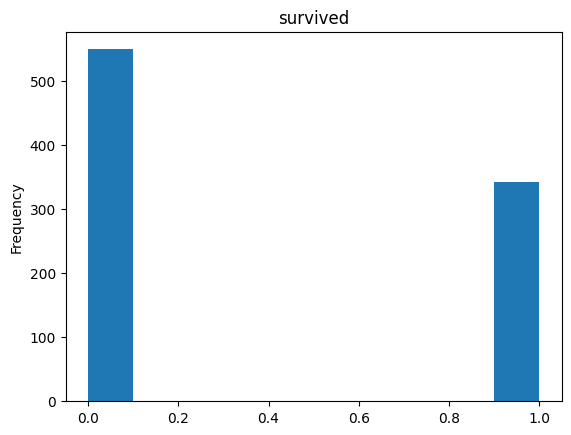

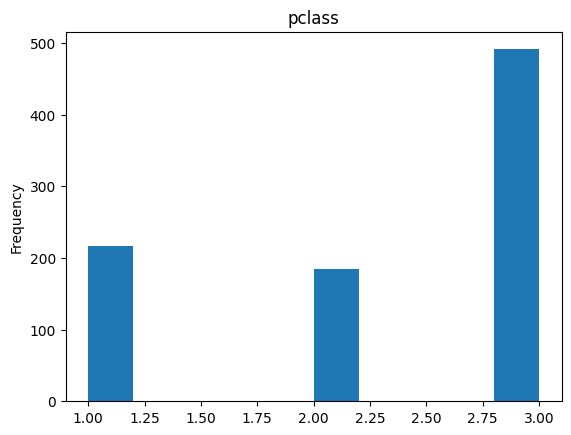

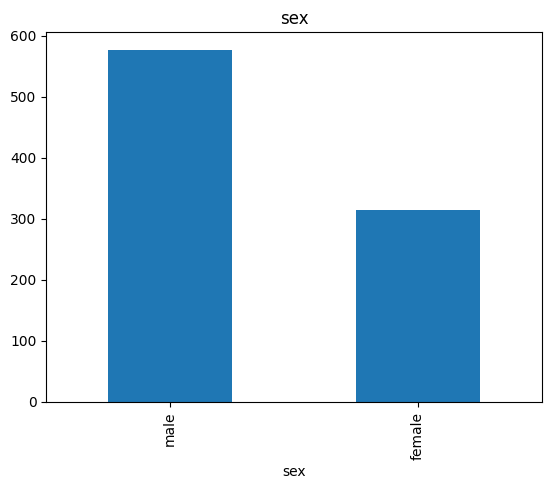

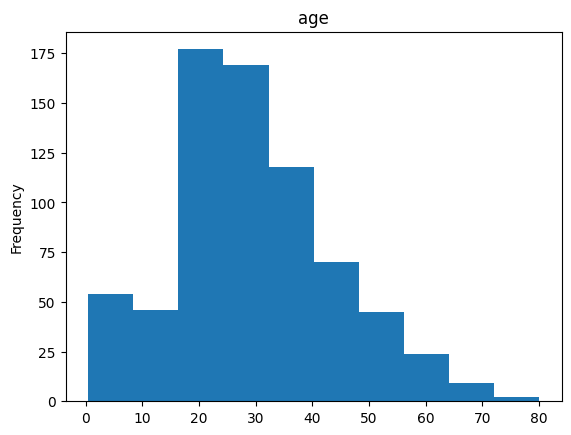

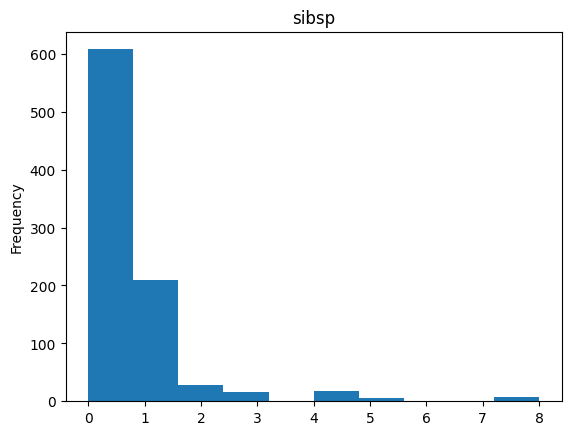

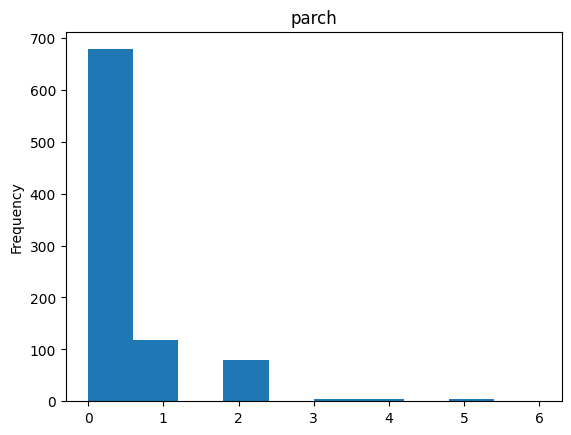

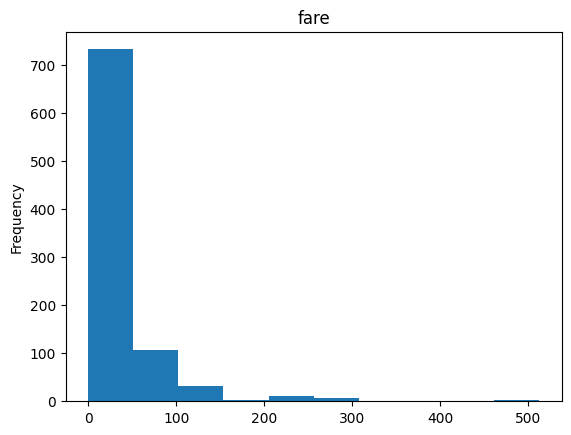

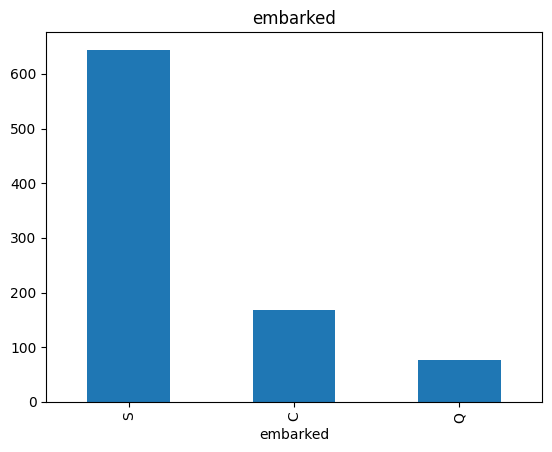

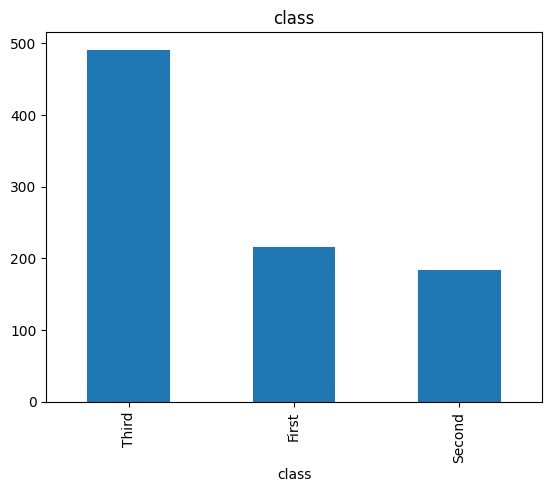

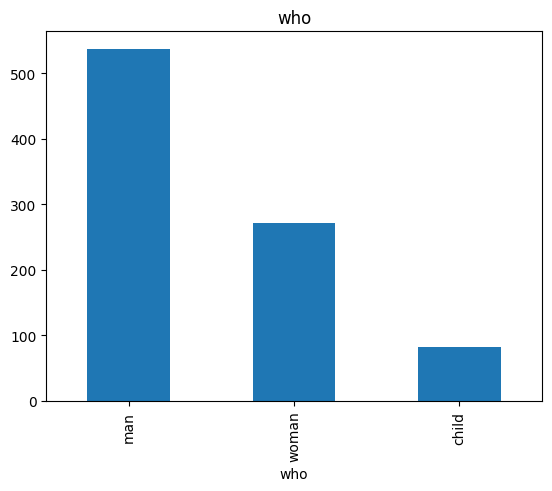

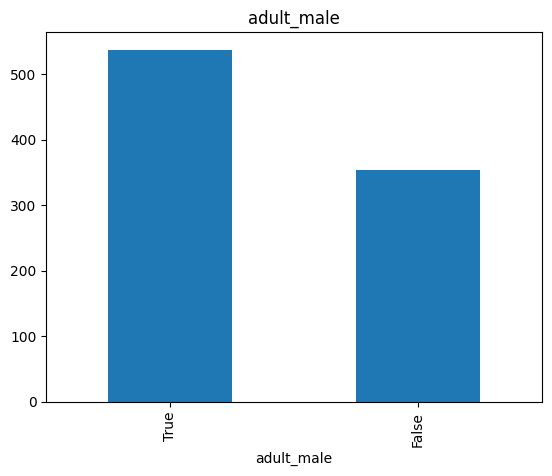

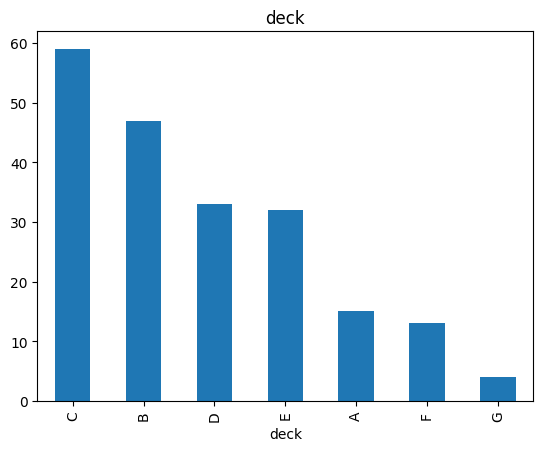

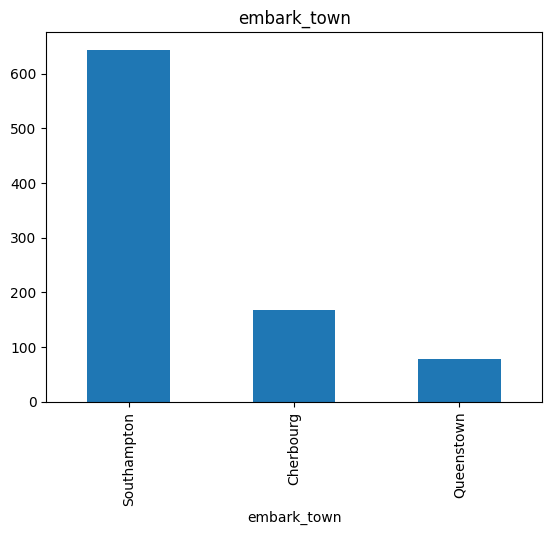

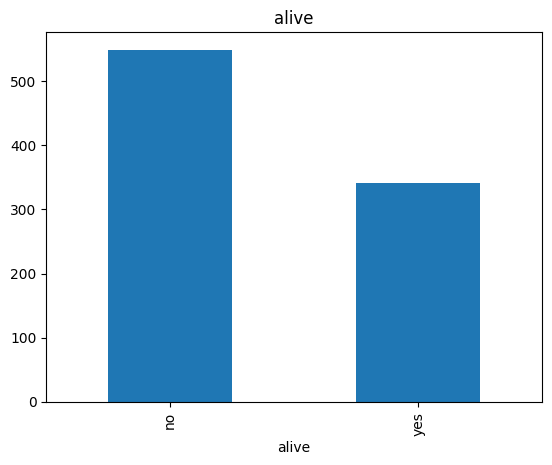

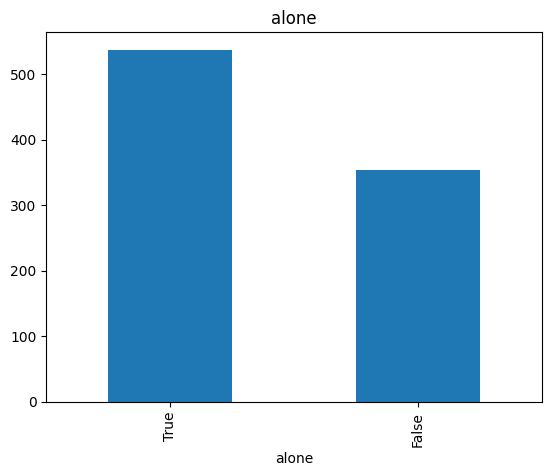

In [30]:
auto_plot(datos)

In [31]:
def auto_plot_export(datos):
    import matplotlib.pyplot as plt
    import openpyxl
    from openpyxl.drawing.image import Image

    # Directorio para guardar imágenes
    ruta = "/Users/rafafons/Library/Mobile Documents/com~apple~CloudDocs/2_Rafa/01-Capacitaciones/IT Academy/sprint 10 python/graficos ejercicios/"

    # Crear libro Excel donde almacenaré los graficos (imagenes)
    wb = openpyxl.Workbook()

    for columna in datos.columns:
        plt.figure()  # nueva figura para evitar mezcla
        
        # Crear gráfico según tipo de columna
        if datos[columna].dtype in ['float64', 'int64']:
            datos[columna].plot.hist()
        elif datos[columna].dtype in ['datetime64[ns]']:
            datos[columna].dt.year.plot.hist()
        else:
            datos[columna].value_counts().plot.bar()

        # Agregar título al gráfico
        titulo_grafico = f"Grafico de {columna}"
        plt.title(titulo_grafico)
        
        # Guardar imagen en directorio
        nombre_img = f"grafico_{columna}.png"
        ruta_img = ruta+nombre_img
        plt.savefig(ruta_img, dpi=200)
        plt.close()

        # Crear hoja en Excel y agregar imagen
        ws = wb.create_sheet(title=titulo_grafico)
        img = Image(ruta_img)
        ws.add_image(img, "A1")

    # Eliminar hoja por defecto que no se usa
    if "Sheet" in wb.sheetnames:
        wb.remove(wb["Sheet"])

    # Guardar Excel final
    wb.save("reporte_graficos.xlsx")
    print("Archivo 'reporte_graficos.xlsx' generado correctamente.")

In [32]:
auto_plot_export(datos)

Archivo 'reporte_graficos.xlsx' generado correctamente.


In [33]:
# NIVEL 3 - Ejercicio 2

# Carga el archivo matriz_distancies.xlsx en pandas, de modo que los nombres de filas y los nombres de columnas sean los de las ciudades.
# Borra "Las Palmas de Gran Canaria" y "Palma" para que podamos realizar el trayecto en coche.

ruta = '/Users/rafafons/Library/Mobile Documents/com~apple~CloudDocs/2_Rafa/01-Capacitaciones/IT Academy/sprint 10 python/matriu_distancies.xlsx'

matriz_distancias = pd.read_excel(ruta)
matriz_distancias.rename(columns={"Unnamed: 0":"Ciudades origen"}, inplace=True)
matriz_distancias = matriz_distancias.set_index(["Ciudades origen"])                       # camio indices a ciudades
matriz_distancias.drop(["Palma", "Las Palmas de Gran Canaria"], axis=1, inplace=True)             # eliminio columnas de ciudades de islas
matriz_distancias.drop(["Palma", "Las Palmas de Gran Canaria"], axis=0, inplace=True)             # eliminio fila de ciudades de islas
matriz_distancias


,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Ciudades origen,,,,,,,,,,,,,
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0
Murcia,471.0,177.0,433.0,408.0,323.0,NaN,606.0,69.0,320.0,510.0,800.0,726.0,465.0
Bilbao,469.0,473.0,703.0,246.0,739.0,606.0,NaN,583.0,618.0,232.0,486.0,223.0,465.0
Alicante,407.0,125.0,495.0,368.0,391.0,69.0,583.0,NaN,379.0,515.0,821.0,722.0,401.0
Córdoba,711.0,421.0,121.0,535.0,133.0,320.0,618.0,379.0,NaN,419.0,589.0,634.0,704.0


In [34]:
# Nos interesa visitar todas las principales ciudades de España recorriendo la mínima distancia posible.
# No hace falta que lo hagas de forma óptima, nos interesa que desarrolles una solución razonable utilizando las herramientas que tienes actualmente.
# Por ejemplo, una aproximación sencilla (que no óptima) sería yendo siempre a la ciudad más cercana que no hayamos visitado todavía

# Haz una función que dada la matriz de distancias y la ciudad de origen, haga una propuesta de ruta que sea lo más corta posible que puedas, 
# devolviendo una lista con el orden de visita. Da también la distancia total recorrida.

def min_Nrutas(matriz_distancias, n):
    ciudades_origen = list(matriz_distancias.index)
    posibles_rutas = []

    # este primer bucle es para explorar los posibles inicios
    for i in range(len(ciudades_origen)):
        inicio = ciudades_origen[i]
        ciudad_inicial = inicio
        distancia = 0
        recorrido =[]
        
        por_visitar = list(matriz_distancias.index)
        por_visitar.remove(inicio)
        
        # aqui voy buscando la ciudad mas cercana (min distancia) a partir de una ciudad inicial
        for j in range(0,(len(por_visitar))):    
            distancia += matriz_distancias.loc[inicio,por_visitar].min()
            destino = matriz_distancias.loc[inicio,por_visitar].idxmin()
            
            recorrido.append(inicio)
            por_visitar.remove(destino)
            inicio = destino
            
        # Agregar la última ciudad
        recorrido.append(inicio)
        
        #almaceno la solucion como un diccionario dentro de la lista "posibles_rutas": 
        posibles_rutas.append({'inicio': ciudad_inicial,
                            'distancia': distancia,
                            'recorrido': recorrido
                            })
        df_posibles_rutas = pd.DataFrame(posibles_rutas)
        pd.set_option('display.max_colwidth', None)             # None = mostrar todo el contenido

    # Mostrar todos los recorridos
    return df_posibles_rutas.nsmallest(n,"distancia")


In [35]:
# (EXTRA) Desde qué ciudad la ruta sería más corta con el algoritmo planteado
min_Nrutas(matriz_distancias=matriz_distancias, n=3)

,inicio,distancia,recorrido
0,Barcelona,2778.0,"[Barcelona, Hospitalet de Llobregat, Zaragoza, Valencia, Alicante, Murcia, Córdoba, Sevilla, Málaga, Valladolid, Gijón, Bilbao, Vigo]"
12,Hospitalet de Llobregat,2784.0,"[Hospitalet de Llobregat, Barcelona, Zaragoza, Valencia, Alicante, Murcia, Córdoba, Sevilla, Málaga, Valladolid, Gijón, Bilbao, Vigo]"
10,Vigo,2873.0,"[Vigo, Gijón, Bilbao, Valladolid, Zaragoza, Valencia, Alicante, Murcia, Córdoba, Sevilla, Málaga, Hospitalet de Llobregat, Barcelona]"
